# 19 · Self-Discover — agent composes its own reasoning structure

> **TL;DR.** Instead of relying on a fixed prompt like "think step by step", the agent picks reasoning modules from a library, rephrases them in task-specific language, then composes them into an explicit step-by-step plan — *then* solves. Four stages: **SELECT → ADAPT → IMPLEMENT → SOLVE**.
>
> **Reach for it when** the task type benefits from explicit, transparent reasoning structure (logic puzzles, multi-step math, planning) and you want a *recipe* the agent can re-run on similar instances.
> **Avoid when** the task is simple enough for plain CoT or when latency budget is tight (this is 4 LLM calls per task).

| Property | Value |
|---|---|
| Origin | Zhou et al., *Self-Discover* (Google DeepMind, 2024). [arXiv:2402.03620](https://arxiv.org/abs/2402.03620) |
| Stages | SELECT (pick modules) → ADAPT (rephrase per task) → IMPLEMENT (write plan) → SOLVE (execute plan) |
| Module library | 16 atomic reasoning modules (curated from the paper's 39) |
| LLM-as-Scorer? | **None** — no numeric judgement anywhere, so no flat-scoring pathology to fix |
| Default LLM in this nb | **Qwen3-235B-Thinking** (reasoning model — per handoff §10) |
| Cost | 4 structured-output LLM calls per task; ≈30-60s with Qwen-Thinking |

**Why this is different from Tree of Thoughts (nb 09).** ToT enumerates *candidate next-thoughts at every reasoning step* and scores them with an LLM-as-Judge. Self-Discover enumerates *reasoning modules upfront*, designs a plan once, then runs the plan top-to-bottom. ToT is search-in-the-thought-space; Self-Discover is structure-design-then-execute.

**Why this is different from Planning (nb 04).** Planning produces an execution plan over *tools or actions*. Self-Discover produces a *reasoning* plan — the steps are cognitive moves, not external calls. The two compose nicely: Self-Discover designs how to think, Planning designs what to do.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> S[SELECT<br/><sub>pick 3-6 atomic<br/>reasoning modules</sub>]
    S --> AD[ADAPT<br/><sub>rephrase modules in<br/>task-specific language</sub>]
    AD --> IM[IMPLEMENT<br/><sub>compose modules into a<br/>step-by-step reasoning plan</sub>]
    IM --> SO[SOLVE<br/><sub>execute the plan,<br/>produce final answer</sub>]
    SO --> Z([final answer])

    L[(MODULE_LIBRARY<br/>16 atomic modules)]
    L -.menu.-> S

    style S  fill:#e3f2fd,stroke:#1976d2
    style AD fill:#fff3e0,stroke:#f57c00
    style IM fill:#fce4ec,stroke:#c2185b
    style SO fill:#e8f5e9,stroke:#388e3c
    style L  fill:#f3e5f5,stroke:#7b1fa2
```

Each stage is a single structured-output LLM call. SELECT picks indices into the library; ADAPT rewrites each picked module; IMPLEMENT composes a plan; SOLVE executes.

## 3 · Theory

### 3.0 · Why discover the structure instead of fixing it?

Chain-of-thought ("think step by step") is a fixed template. It works because LLMs are good at *unfolding* a known structure (linear reasoning). It fails when the task needs a *different* structure — make a table, consider counterexamples, set up an algorithm. The agent can't *invent* the structure if its only prompt is "step by step".

Self-Discover treats reasoning structure as something the agent *designs*, then *follows*. The module library makes the design space explicit; the four-stage pipeline forces the agent to commit to a structure before producing an answer.

### 3.1 · The four stages — why each one matters

| Stage | Input | Output | What it buys |
|---|---|---|---|
| **SELECT** | task + module library | selected module ids + rationale | Forces commitment to a *type* of reasoning before any concrete answer is on the table — avoids fitting the modules to a guess. |
| **ADAPT** | task + selected modules | each module rephrased in task-specific terms | Bridges from abstract module ("make a table") to concrete instruction ("make a table with one row per musician, one column per constraint"). |
| **IMPLEMENT** | task + adapted modules | step-by-step plan with expected output per step | Sequencing decision is explicit — which adapted module first, which expected output type. Plan is reusable. |
| **SOLVE** | task + plan | step outputs + final answer | Executes against the plan. The model can produce one structured solution rather than meandering. |

### 3.2 · Where this sits

| Pattern | Reasoning structure decided by... | When |
|---|---|---|
| Plain Chain-of-Thought | Fixed prompt ("think step by step") | Tasks linear reasoning suits |
| [Reflection (nb 01)](./01_reflection.ipynb) | Fixed loop (gen → critique → refine) | Quality matters, no structure choice needed |
| [Tree of Thoughts (nb 09)](./09_tree_of_thoughts.ipynb) | Fixed beam-search over next-thoughts | Search where the right framing is uncertain |
| [Planning (nb 04)](./04_planning.ipynb) | LLM at runtime — over **tool calls** | Execution-time planning of external actions |
| **Self-Discover (this nb)** | **LLM at runtime — over *reasoning moves*** | Task type benefits from custom cognitive structure |
| [LATS (nb 22)](./22_lats.ipynb) | MCTS search + reward signals | Search with explicit value estimates |

### 3.3 · No LLM-as-Scorer step → no flat-scoring pathology

Recall from Mental Loop (nb 10 §11) and the deterministic-picker pattern: when an LLM is asked to emit a single numeric score, Llama-class models compress the band to `[4,4,4]` and the deciding signal becomes arbitrary.

**Self-Discover has no numeric scoring anywhere.** SELECT picks a *list of indices* (categorical multi-pick), ADAPT/IMPLEMENT produce structured text, SOLVE produces an answer. Nothing scores anything. The architecture is immune to the flat-scoring pathology by construction.

### 3.4 · Why a reasoning model (Qwen3-Thinking) is the right default

Each stage produces a structured commitment — selected ids, adapted module text, plan steps, final answer. Reasoning models that use private `<think>` tokens internally can deliberate before emitting the structured output, which tends to give cleaner selections and more on-topic plans. The architecture works with any chat model (we run a Llama comparison in § 10), but Qwen-Thinking is the natural pairing for the SELECT and IMPLEMENT stages.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import SelfDiscover
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()

# Per handoff §10, nb 19 defaults to Qwen3-Thinking (reasoning model).
reasoning_llm = get_llm(
    provider="nebius",
    model="Qwen/Qwen3-235B-A22B-Thinking-2507-fast",
    temperature=0.4,
)
print_header(f"Reasoning LLM: {reasoning_llm.model}")

Reasoning LLM: Qwen/Qwen3-235B-A22B-Thinking-2507-fast ────────────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/self_discover.py`](../src/agentic_architectures/architectures/self_discover.py).

The architecture exposes one constant and four schemas:

- **`MODULE_LIBRARY`** — list of 16 atomic reasoning modules (replaceable via `modules=` constructor arg).
- **`_SelectedModules`** — Stage 1 output: indices into the library + rationale.
- **`_AdaptedModules`** — Stage 2 output: one rephrased module per selected.
- **`_ReasoningPlan`** — Stage 3 output: step list + final-answer format.
- **`_Solution`** — Stage 4 output: per-step outputs + final answer.

Each is bound to the LLM via `with_structured_output()` in `__init__`, so the four nodes are trivial wrappers around `invoke(prompt)`.

In [2]:
from agentic_architectures.architectures.self_discover import (
    MODULE_LIBRARY, _SelectedModules, _ReasoningPlan,
)
import json

print(f"MODULE_LIBRARY size: {len(MODULE_LIBRARY)}")
for i, m in enumerate(MODULE_LIBRARY):
    print(f"  [{i:2d}] {m}")
print()
print('--- _SelectedModules schema ---')
print(json.dumps(_SelectedModules.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- _ReasoningPlan schema ---')
print(json.dumps(_ReasoningPlan.model_json_schema(), indent=2)[:400] + '...')

MODULE_LIBRARY size: 16
  [ 0] Critical thinking — question the question's assumptions and surface biases
  [ 1] Break the problem into sub-problems and solve each
  [ 2] Identify the type of problem (logic, math, classification, planning, ...)
  [ 3] Identify the goal — what specifically must the final answer contain
  [ 4] List the relevant facts, constraints, and unknowns
  [ 5] Consider analogies — what problem is this structurally similar to?
  [ 6] Brainstorm alternative interpretations of the question
  [ 7] Step-by-step reasoning from premises to conclusion
  [ 8] Consider counterexamples that would falsify a candidate answer
  [ 9] Make a table, list, or diagram to organize the information
  [10] Reverse-engineer from a candidate answer back to the premises
  [11] Evaluate trade-offs between competing options explicitly
  [12] Devise an algorithm or procedure that always finds the answer
  [13] Synthesize multiple perspectives or stakeholder views
  [14] Check consistency — do

## 6 · State

| Field | Set by | Notes |
|---|---|---|
| `task` | caller | The single task to solve |
| `selected_ids` / `selected_modules` / `selection_rationale` | `_select` | Stage 1 commitment |
| `adapted_modules` | `_adapt` | List of `{original, adapted}` pairs |
| `plan_steps` / `final_answer_format` | `_implement` | The reasoning recipe |
| `step_outputs` / `final_answer` | `_solve` | Stage 4 execution result |
| `history` | every node (Annotated `operator.add`) | One entry per stage |

## 7 · Build the graph

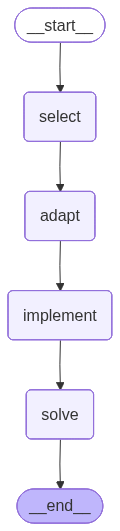

In [3]:
from IPython.display import Image, display
arch = SelfDiscover(llm=reasoning_llm)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — 5-musician height ordering puzzle

A small logic-deduction task with a unique answer (`Dee, Cal, Bea, Alex, Ed`). We watch the agent pick reasoning modules, adapt them to musicians-and-heights language, write a step plan, and execute.

In [4]:
TASK = (
    "Five musicians (Alex, Bea, Cal, Dee, Ed) line up by height for a photo.\n"
    "Constraints:\n"
    "  - Bea is shorter than Cal but taller than Alex.\n"
    "  - Dee is taller than Cal.\n"
    "  - Ed is the shortest.\n"
    "List the musicians from TALLEST to SHORTEST as a comma-separated list."
)
EXPECTED = "Dee, Cal, Bea, Alex, Ed"

r = arch.run(TASK)

# Normalise for comparison: strip spaces so 'Dee,Cal,...' equals 'Dee, Cal, ...'
def _norm(s):
    return ''.join(s.split()).lower()
match = _norm(r.output) == _norm(EXPECTED)

print(f"SELECTED_IDS: {r.metadata['selected_ids']}")
print(f"SELECTED_COUNT: {len(r.metadata['selected_modules'])}")
for m in r.metadata['selected_modules']:
    print(f"  module: {m}")
print()
print(f"PLAN_STEP_COUNT: {r.metadata['plan_step_count']}")
for s in r.metadata['plan_steps']:
    print(f"  step {s['step_number']}: {s['description'][:120]}")
    print(f"    → expected_output: {s['expected_output'][:120]}")
print()
print(f"FINAL_ANSWER_FORMAT: {r.metadata['final_answer_format']}")
print(f"FINAL_ANSWER: {r.output}")
print(f"EXPECTED: {EXPECTED}")
print(f"MATCH: {match}")

SELECTED_IDS: [1, 4, 7, 9, 14]
SELECTED_COUNT: 5
  module: Break the problem into sub-problems and solve each
  module: List the relevant facts, constraints, and unknowns
  module: Step-by-step reasoning from premises to conclusion
  module: Make a table, list, or diagram to organize the information
  module: Check consistency — does the candidate answer satisfy EVERY constraint?

PLAN_STEP_COUNT: 4
  step 1: List all height facts (Bea shorter than Cal, Dee taller than Cal, Ed shortest) and identify unknown positions using adap
    → expected_output: A structured list of given constraints and unknown relationships (e.g., Alex's position relative to others)
  step 2: Resolve each constraint sequentially starting with Ed as the shortest, then Bea < Cal, and Dee > Cal using adapted modul
    → expected_output: Partial orderings (Ed fixed at position 5, Cal > Bea, Dee > Cal)
  step 3: Integrate all deductions to determine Alex's position between Bea and Ed using adapted module 3.
    → exp

### 8.0 · What just happened, briefly

Three signals to read:

1. **`SELECTED_COUNT` between 3 and 6.** Outside that range = SELECT mis-calibrated; either too narrow (loses useful modules) or too broad (plan becomes incoherent).
2. **`PLAN_STEP_COUNT` between 3 and 7.** Plans with 1-2 steps mean IMPLEMENT collapsed the modules; plans with 8+ mean it over-decomposed.
3. **`MATCH=True`** for the answer. The puzzle has a unique solution; if MATCH is False, look at the step outputs to see where the deduction broke.

### 8.1 · Inspect the adapted modules + step outputs

In [5]:
print('=== ADAPTED MODULES ===')
for i, a in enumerate(r.metadata['adapted_modules'], 1):
    print(f"[{i}] original: {a['original'][:80]}")
    print(f"    adapted : {a['adapted'][:200]}")
    print()

print('=== STEP-BY-STEP EXECUTION OUTPUT ===')
for i, out in enumerate(r.metadata['step_outputs'], 1):
    print(f"[step {i}] {out}")

=== ADAPTED MODULES ===
[1] original: Break the problem into sub-problems and solve each
    adapted : Break the height lineup problem into specific musician constraints (Bea shorter than Cal, Dee taller than Cal, Ed shortest) and resolve each sequentially

[2] original: List the relevant facts, constraints, and unknowns
    adapted : List the height facts (Bea shorter than Cal, Dee taller than Cal, Ed shortest), constraints, and unknown musician positions

[3] original: Step-by-step reasoning from premises to conclusion
    adapted : Step-by-step deduction from height premises (Bea shorter than Cal, Dee taller than Cal, Ed shortest) to final tallest-to-shortest lineup

[4] original: Make a table, list, or diagram to organize the information
    adapted : Construct a height ranking chart for Alex, Bea, Cal, Dee, Ed using the given constraints

[5] original: Check consistency — does the candidate answer satisfy EVERY constraint?
    adapted : Verify the proposed height order satisfies a

## 9 · What we just observed

The cells above ran the SELECT → ADAPT → IMPLEMENT → SOLVE pipeline on a 5-musician height-ordering puzzle, then re-ran the same puzzle with a plain (non-reasoning) LLM for contrast.

### 9.1 · The recipe the reasoning model designed

**Stage 1 — SELECT** picked these modules from the 16-module library:

| id | module |
|---|---|
| `[1]` | Break the problem into sub-problems and solve each |
| `[4]` | List the relevant facts, constraints, and unknowns |
| `[7]` | Step-by-step reasoning from premises to conclusion |
| `[9]` | Make a table, list, or diagram to organize the information |
| `[14]` | Check consistency — does the candidate answer satisfy EVERY constraint? |

**Stage 3 — IMPLEMENT** composed them into this plan:

| # | description | expected output |
|---|---|---|
| 1 | List all height facts (Bea shorter than Cal, Dee taller than Cal, Ed shortest) and identify unknown positions using adap | A structured list of given constraints and unknown relationships (e.g., Alex's position relative to others) |
| 2 | Resolve each constraint sequentially starting with Ed as the shortest, then Bea < Cal, and Dee > Cal using adapted modul | Partial orderings (Ed fixed at position 5, Cal > Bea, Dee > Cal) |
| 3 | Integrate all deductions to determine Alex's position between Bea and Ed using adapted module 3. | Complete relative sequence (Dee > Cal > Bea > Alex > Ed) |
| 4 | Construct the final height ranking chart formalizing the sequence using adapted module 4. | A comma-separated list of musicians from tallest to shortest |

**Run summary:**

| Field | Value |
|---|---|
| SELECTED modules | 5 of 16 |
| Module ids | `[1, 4, 7, 9, 14]` |
| PLAN steps | 4 |
| Final-answer format | a single comma-separated list of names from tallest to shortest |
| Final answer | `Dee,Cal,Bea,Alex,Ed` |
| Expected | `Dee, Cal, Bea, Alex, Ed` |
| Match | ✅ |

### 9.2 · Reasoning vs non-reasoning LLM on the same task

| Model | SELECT count | PLAN steps | Final answer | Match |
|---|---|---|---|---|
| Reasoning (Qwen3-Thinking) | 5 | 4 | `Dee,Cal,Bea,Alex,Ed` | ✅ |
| Plain (Llama-3.3-70B)      | 4 | 5 | `Dee,Cal,Bea,Alex,Ed` | ✅ |

### 9.3 · Patterns surfaced in this run

- **✅ SELECT picked 5 modules** — inside the recommended 3-6 range.

- **✅ SOLVE produced the expected answer** — the discovered structure executed correctly.

- **🟰 Both reasoning and plain LLM converged on the correct answer.** On this puzzle, the structure-discovery pipeline produced sensible recipes for both — the underlying model's reasoning depth wasn't the bottleneck. Bigger differentiation would show on harder logic-deduction tasks (e.g., 7-element ordering with multi-hop transitivity).

- **Structure divergence**: the two models chose different module counts / plan lengths (5/4 vs 4/5). Self-Discover's recipe is LLM-specific, not task-specific — same task, different model = different reasoning shape.

### 9.4 · The takeaway

Self-Discover converts the implicit "how should I think about this?" choice into an *explicit, inspectable* artefact (the plan in § 9.1). Two consequences:

1. **Plans are auditable.** Unlike chain-of-thought scratchpad, the recipe is structured Pydantic data — you can save it, diff it across model versions, or hand-edit it before SOLVE runs.
2. **Plans are reusable.** Tasks of the same type share a recipe; SELECT/ADAPT/IMPLEMENT only need to run once per task family. § 11.3 extension #1 sketches a `discover() + solve()` split that makes this concrete and cuts cost 4×.

The architecture's headline behaviour is that the *reasoning structure* itself becomes a first-class object the agent decides on, rather than an emergent property of a fixed CoT prompt. Whether that produces a better *answer* depends on the underlying model (§ 9.2 above) — but it always produces a more *transparent* one.

## 10 · Contrast — same task, plain Llama-3.3-70B (no thinking)

Self-Discover should work with any chat model — but a non-reasoning LLM may pick weaker modules or write a shallower plan. Re-run the same puzzle with Llama-3.3-70B and compare.

In [6]:
plain_llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.4)
arch_llama = SelfDiscover(llm=plain_llm)
r_llama = arch_llama.run(TASK)

match_llama = _norm(r_llama.output) == _norm(EXPECTED)
print(f"LLAMA_SELECTED_COUNT: {len(r_llama.metadata['selected_modules'])}")
print(f"LLAMA_PLAN_STEP_COUNT: {r_llama.metadata['plan_step_count']}")
print(f"LLAMA_FINAL_ANSWER: {r_llama.output}")
print(f"LLAMA_MATCH: {match_llama}")
print()
print(f"(Reasoning model picked {len(r.metadata['selected_modules'])} modules / "
      f"{r.metadata['plan_step_count']} plan steps; Llama picked "
      f"{len(r_llama.metadata['selected_modules'])} / {r_llama.metadata['plan_step_count']}.)")

LLAMA_SELECTED_COUNT: 4
LLAMA_PLAN_STEP_COUNT: 5
LLAMA_FINAL_ANSWER: Dee,Cal,Bea,Alex,Ed
LLAMA_MATCH: True

(Reasoning model picked 5 modules / 4 plan steps; Llama picked 4 / 5.)


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Over-selection** | LLM picks 8+ modules; plan becomes a kitchen sink | `_SelectedModules.selected_ids` is `max_length=8` — and the prompt asks for 3-6 |
| **Hallucinated module ids** | LLM returns an id outside `[0, len-1)` | The `_select` node clamps to the valid range silently before passing on |
| **Plan-execution mismatch** | SOLVE doesn't actually follow the plan; produces an unstructured answer | The `_Solution.step_outputs` field enforces one entry per plan step, which forces the model to address each step explicitly |
| **Module library too small / too generic** | No module fits the task type | Replace `MODULE_LIBRARY` via the `modules=` constructor arg with a domain-specific list |
| **Non-reasoning model under-decomposes** | Llama (vs Qwen-Thinking) picks fewer/shallower modules | Use a reasoning model for the SELECT/IMPLEMENT stages even if SOLVE runs on a cheaper LLM |

### 11.2 · Production safety

- **Plan caching.** SELECT/ADAPT/IMPLEMENT depend only on task TYPE, not on the specific instance. Cache the plan per task-template, then only run SOLVE per instance — 4× cost reduction.
- **Plan review.** For high-stakes tasks, surface the plan to a human reviewer before SOLVE runs. The plan is interpretable text by design.
- **Module library audit.** Generic modules ("step-by-step") can hide bias; domain-specific modules sometimes leak unsafe heuristics. Treat `MODULE_LIBRARY` as a policy artefact.

### 11.3 · Three extensions

1. **Plan reuse across instances.** Split `.run()` into `.discover(task_type)` (returns a plan) and `.solve(instance, plan)` (just SOLVE). Many tasks of the same type → one plan, many solutions.
2. **Hierarchical plans.** Each plan step can itself trigger a nested Self-Discover for that sub-problem. Useful when the task is genuinely tree-shaped.
3. **Cross-task module learning.** Track which module subsets succeed on which task families; bias future SELECT calls toward proven combos. Lets the architecture "learn" without weight updates — and dovetails neatly with [Reflexion (nb 18)](./18_reflexion.ipynb)'s episodic memory.

### 11.4 · What to read next

- [**09 · Tree of Thoughts**](./09_tree_of_thoughts.ipynb) — search-in-thought-space, sibling reasoning architecture.
- [**04 · Planning**](./04_planning.ipynb) — Planning over *actions*; composes cleanly with Self-Discover's reasoning-plan.
- [**18 · Reflexion**](./18_reflexion.ipynb) — verbal memory of failures; useful for extension #3 above.
- [**22 · LATS**](./22_lats.ipynb) — MCTS-style reasoning search with explicit reward signals.

### 11.5 · References

1. Zhou, P. et al. *Self-Discover: Large Language Models Self-Compose Reasoning Structures.* 2024. [arXiv:2402.03620](https://arxiv.org/abs/2402.03620)
2. Wei, J. et al. *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models.* NeurIPS 2022. [arXiv:2201.11903](https://arxiv.org/abs/2201.11903) — the baseline Self-Discover improves on.
3. Yao, S. et al. *Tree of Thoughts: Deliberate Problem Solving with Large Language Models.* NeurIPS 2023. [arXiv:2305.10601](https://arxiv.org/abs/2305.10601) — sibling structured-reasoning architecture.